---

# Dimensionality Reduction with PCA

Principal Component Analysis (PCA) is an unsupervised dimensionality reduction technique that transforms high-dimensional data into a lower-dimensional space while preserving as much variance as possible. It does this by finding the directions (principal components) along which the data varies the most.

PCA is useful for:
- Visualizing high-dimensional data in 2D or 3D
- Reducing noise and redundant features before model training
- Speeding up downstream machine learning algorithms

In this notebook, we apply PCA to the Breast Cancer Wisconsin dataset to reduce 30 features down to 2 principal components and visualize how well the classes separate in the reduced space.

---

In [8]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn PCA and preprocessing tools
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

---

## Loading and Exploring the Data

---

In [9]:
# Load the Breast Cancer dataset
df = pd.read_csv("breast_cancer.csv")

# Check dimensions and preview
print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---

## Defining Features and Scaling

PCA is sensitive to feature scale so we standardize before applying it.

---

In [10]:
# Separate features and target
X = df.drop(columns='target').values
y = df['target'].values

# Standardize features before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)

Feature matrix shape: (569, 30)


---

## Explained Variance

Before reducing dimensions, we check how much variance each principal component explains to decide how many components to keep.

---

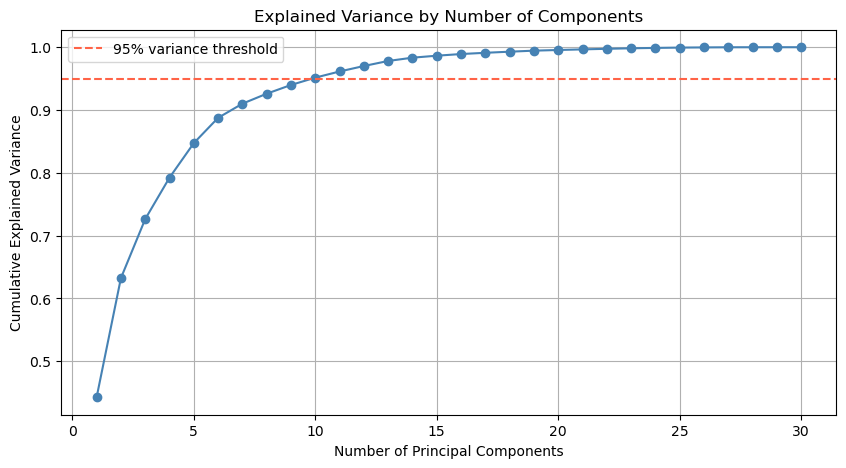

Components needed to explain 95% of variance: 10


In [11]:
# Fit PCA with all 30 components to analyze explained variance
pca_full = PCA(n_components=30)
pca_full.fit(X_scaled)

# Plot explained variance ratio
plt.figure(figsize=(10, 5))
plt.plot(range(1, 31), np.cumsum(pca_full.explained_variance_ratio_), marker='o', color='steelblue')
plt.axhline(y=0.95, color='tomato', linestyle='--', label='95% variance threshold')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Number of Components")
plt.legend()
plt.grid(True)
plt.show()

print(f"Components needed to explain 95% of variance: {np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1}")

---

## Reducing to 2 Components for Visualization

We reduce to 2 principal components to visualize the data in 2D and see how well the two classes separate.

---

In [12]:
# Apply PCA with 2 components for visualization
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]:.3f}")
print(f"Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]:.3f}")
print(f"Total variance explained: {pca_2d.explained_variance_ratio_.sum():.3f}")

Variance explained by PC1: 0.443
Variance explained by PC2: 0.190
Total variance explained: 0.632


---

## Visualizing the Reduced Data

---

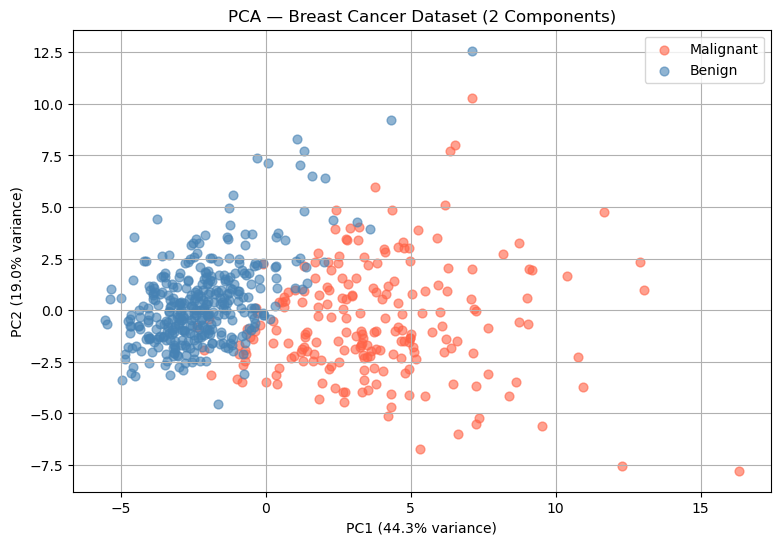

In [13]:
# Plot the data in the 2D PCA space
plt.figure(figsize=(9, 6))

for label, color, name in zip([0, 1], ['tomato', 'steelblue'], ['Malignant', 'Benign']):
    mask = y == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=color, s=40, alpha=0.6, label=name)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA — Breast Cancer Dataset (2 Components)")
plt.legend()
plt.grid(True)
plt.show()

---

## PCA as a Preprocessing Step

PCA can also be used to reduce dimensionality before training a classifier. Let's compare the accuracy of logistic regression trained on the full 30 features vs just the top 10 principal components.

---

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train on full features
model_full = LogisticRegression(max_iter=1000, random_state=42)
model_full.fit(X_train, y_train)
acc_full = accuracy_score(y_test, model_full.predict(X_test))

# Train on 10 PCA components
pca_10 = PCA(n_components=10)
X_train_pca = pca_10.fit_transform(X_train)
X_test_pca = pca_10.transform(X_test)

model_pca = LogisticRegression(max_iter=1000, random_state=42)
model_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, model_pca.predict(X_test_pca))

print(f"Accuracy with all 30 features:      {acc_full:.3f}")
print(f"Accuracy with 10 PCA components:    {acc_pca:.3f}")

Accuracy with all 30 features:      0.974
Accuracy with 10 PCA components:    0.982


---

## Summary

In this notebook we applied PCA to the Breast Cancer Wisconsin dataset to reduce 30 features down to a lower-dimensional representation. Key findings:

- Just 10 principal components capture 95% of the variance in the data
- The 2D PCA plot shows clear separation between malignant and benign tumors
- A logistic regression model trained on 10 PCA components achieved slightly higher accuracy (98.2%) than one trained on all 30 features (97.4%)
- This demonstrates that PCA can reduce dimensionality while preserving or even improving downstream model performance by removing noisy or redundant features

---